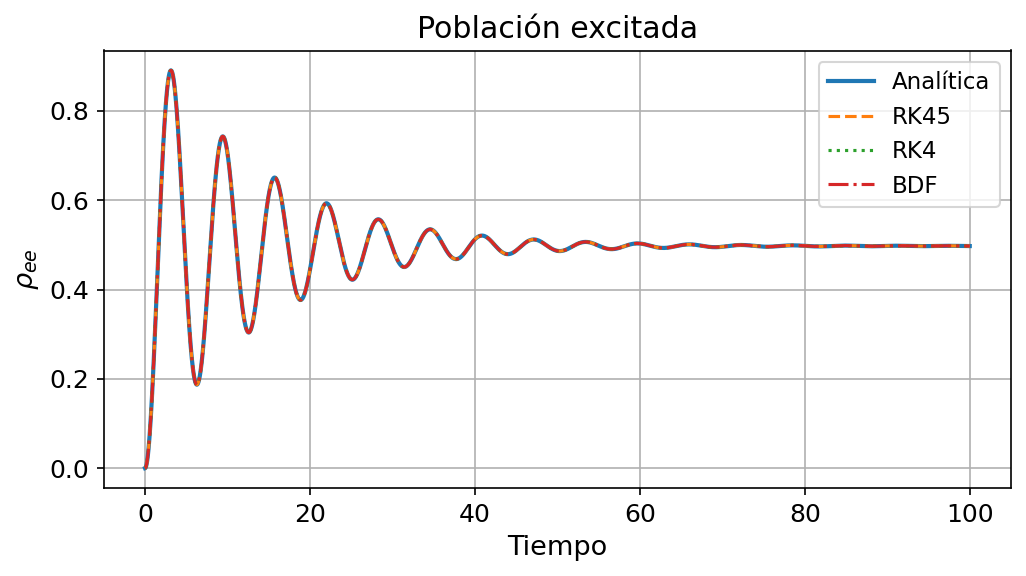

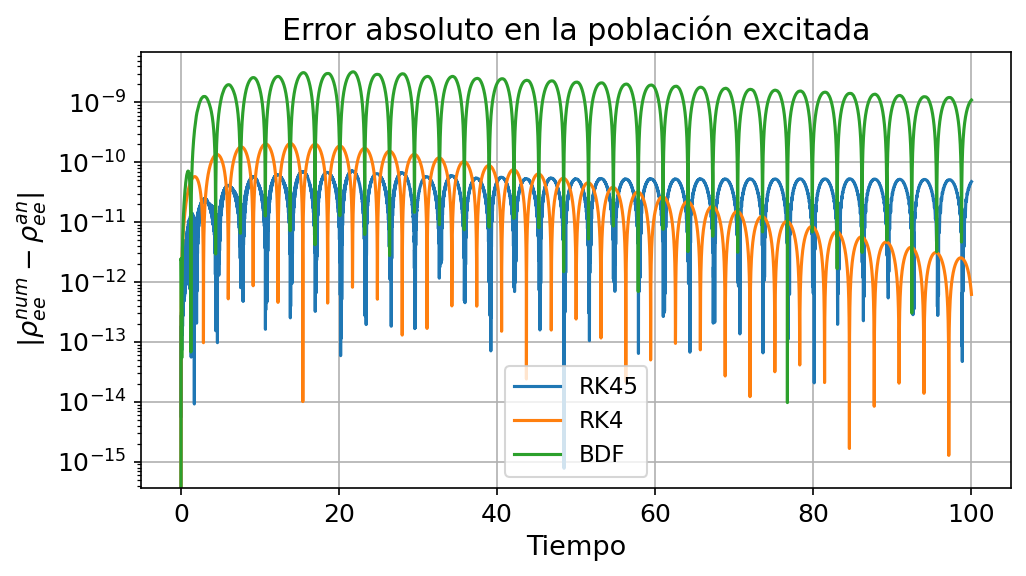

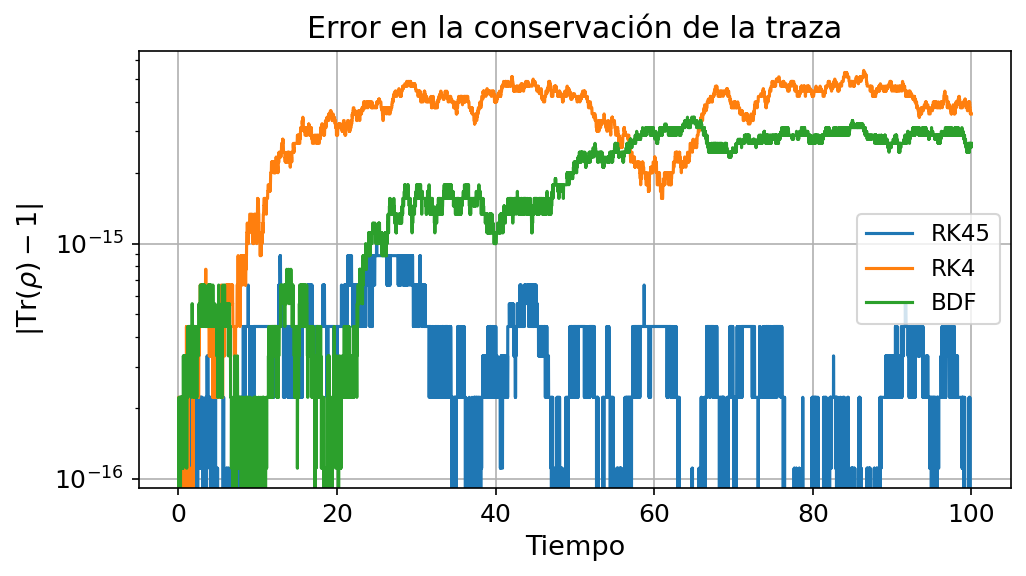

In [1]:
#########################################################################
#                     Imports y estilo de graficos                      #
#########################################################################

import numpy as np                                                                       #Matrices, arreglos e integrales
import matplotlib.pyplot as plt                                                          #Graficos
import time                                                                              #Tiempos de ejecucion
from scipy.integrate import solve_ivp                                                    #Integradores

plt.rcParams.update({                                                                    #Estilo de graficos
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 12,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
    "axes.grid": True,
})

#########################################################################
#                        Sistema de dos niveles                         #
#########################################################################

#########################################
#                Matrices               #
#########################################

sigma_x=np.array([[0,1],[1,0]], dtype=complex)                                           #Matrices de Pauli
sigma_y=np.array([[0,-1j],[1j,0]], dtype=complex)
sigma_z=np.array([[1,0],[0,-1]], dtype=complex)
sigma_plus=np.array([[0,1],[0,0]], dtype=complex)                                        #Operador de subida
sigma_minus=np.array([[0,0],[1,0]], dtype=complex)                                       #Operador de bajada

#########################################
#         Parametros del sistema        #
#########################################

#Variables

w_0=1                                                                                    #Frecuencia de transicion del atomo
w=w_0                                                                                    #Frecuencia del laser
delta=w-w_0                                                                              #Detuning
Omega=1                                                                                  #Frecuencia de Rabi
Gamma=0.1*Omega                                                                          #Tasa disipativa

#Hamiltoniano en el marco rotante (Consideramos Omega Real)

H=-(delta/2) * sigma_z + (Omega/2) * sigma_x

#Operadores relevantes y tasas disipativas

Loper=[sigma_minus]                                                                      #Lista de operadores relevantes 
rates=[Gamma]                                                                            #Lista de tasas disipativas 

#Condicion inicial: Comenzamos en el estado fundamental del sistema

Mdensity_0=np.array([[0,0],[0,1]], dtype=complex).flatten()                              #Arreglo matricial para estado fundamental

#Arreglo temporal

t_eval=np.linspace(0,100,10000)

#########################################################################
#                  Ecuacion Maestra de Lindblad                         #
#########################################################################

def Lindblad(t, matrixdensity_flat, H, Loper, rates):
    dim=H.shape[0]                                                                       #Entrega la dimension del sistema
    Mdensity=matrixdensity_flat.reshape((dim, dim))                                      #Convierte el vector de matriz densidad rho su forma matricial

    #Conmutador
    
    C=-1j * (H@Mdensity-Mdensity@H)                                                      #Conmutador de ecuacion maestra -i[H,rho]

    #Disipacion

    D=np.zeros_like(Mdensity, dtype=complex)                                             #Crea matriz de ceros con la dimension de la matriz densidad
    for L, gamma in zip(Loper, rates):                                                   #Ciclo para considerar todas las disipaciones del sistema total
        Ldagger=L.conj().T                                                               #Conjuga el operador considerado en el superoperador de Linblad
        D+=gamma*(L@Mdensity@Ldagger)                                                    #Se agrega pirmer termino disipativo gamma_{k}L_{k}L_{k}^{\dagger}
        D-=0.5*gamma*(Ldagger@L@Mdensity+Mdensity@Ldagger@L)                             #Se agrega segundo termino disipativo -\frac{gamma_{k}}{2}{L_{k}^{\dagger}L_{k},rho}

    dmatrixdensity_dt= C+D                                                               #Ecuacion maestra
    return dmatrixdensity_dt.flatten()                                                   #Pasa a vector la forma matricial ya que el integrador que ocuparemos solo trata con vectores [cdot{p_ee}, cdot{p_eg}, cdot{p_ge}, cdot{p_gg}]

#########################################################################
#                 Estructura de Soluciones (delta=0)                    #
#########################################################################
##########################################
#           Solucion Analitica           #
##########################################

mu=np.sqrt(Omega**2-(Gamma/4)**2)

def p_ee(t):                                                                             #Poblacion en el estado excitado
    A=(Omega**2)/(Gamma**2+2*Omega**2)

    return A*(1-np.exp(-3*Gamma*t/4)*(np.cos(mu*t)+(3*Gamma/(4*mu))*np.sin(mu*t)))

def p_eg(t):                                                                             #Coherencia Cuantica
    A=(-1j*Omega*Gamma)/(Gamma**2+2*Omega**2)

    return A*(1-np.exp(-3*Gamma*t/4)*(np.cos(mu*t)+((Gamma/(4*mu))-(Omega**2/(mu*Gamma)))*np.sin(mu*t)))

##########################################
#               Metodo RK4               #
##########################################

def RK4_step(f, t, y, h, *args):                                                         #f es la ecuacion diferencial a resolver, t el tiempo actual, y es el estado actual del sistema (en nuestro caso, la matriz densidad vectorizada, h es el paso temporal y *args son los argumentos que necesitamos considerar (H, operadores,tasas ))
    k1=f(t, y, *args)
    k2=f(t+h/2, y+h*k1/2, *args)
    k3=f(t+h/2, y+h*k2/2, *args)
    k4=f(t+h, y+h*k3, *args)

    return y+(h/6)*(k1+2*k2+2*k3+k4)

def RK4_solver(f, t_span, y0, h, *args):
    t0, tf=t_span                                                                        #Del tiempo definido de integracion toma el inicial t0 y el final tf
    t_values=np.arange(t0, tf+h, h)                                                      #Forma un arreglo de tiempo partiendo desde t0 y para el siguiente valor de t le suma el paso temporal
    y_values=np.zeros((len(t_values), len(y0)), dtype=complex)                           #Arreglo para guardar la solucion numerica
    y_values[0]=y0                                                                       #Condicion inicial
    for i in range(len(t_values)-1):
        y_values[i+1]=RK4_step(f,t_values[i],y_values[i],h,*args)

    return t_values, y_values

##########################################
#      Metodo BDF Y RK45 (En Scipy)      #
##########################################

#########################################################################
#                          Funciones Auxiliares                         #
#########################################################################

def density_elements(solution):                                                          #Funcion que revibe como input la solucion de cada metodo numerico
    Mdensity_t=solution.reshape(-1,2,2)                                                  #Reconstruye el vector a su forma matricial original (el -1 indica al comando numpy que reconozca cuantas matrices hay)
    Mdensity_ee=np.real([Mdensity[0,0] for Mdensity in Mdensity_t])                      #Extrae la informacion la poblacion excitada por cada tiempo
    Mdensity_gg=np.real([Mdensity[1,1] for Mdensity in Mdensity_t])
    Mdensity_eg=np.array([Mdensity[0,1] for Mdensity in Mdensity_t])
    Mdensity_ge=np.array([Mdensity[1,0] for Mdensity in Mdensity_t])

    return Mdensity_ee, Mdensity_gg, Mdensity_eg, Mdensity_ge                            #Retorna cada elemento de la matriz densidad

#########################################################################
#                           Validacion Numerica                         #
#########################################################################

##########################################
#          Soluciones Analiticas         #
##########################################

Mdensity_ee_analitica=p_ee(t_eval)
Mdensity_eg_analitica=p_eg(t_eval)

##########################################
#               Metodo RK45              #
##########################################

inicio_RK45=time.perf_counter()                                                          #Registramos el tiempo de ejecucion de cada metodo

sol_RK45=solve_ivp(Lindblad,(0,100),Mdensity_0,t_eval=t_eval,args=(H,Loper,rates), rtol=1e-10, atol=1e-12)   #Entrega los tiempos y la solucion en cada instante

fin_RK45=time.perf_counter()                     

tiempo_RK45=fin_RK45-inicio_RK45                                                         #Obtencion de tiempo de ejecucion
t_RK45=sol_RK45.t                                                                                            #Tomamos solo el tiempo de la solucion anterior
Mdensity_ee_RK45, Mdensity_gg_RK45, Mdensity_eg_RK45, Mdensity_ge_RK45 = density_elements(sol_RK45.y.T)      #Entrega solucion de cada elemento en el tiempo dado

##########################################
#                Metodo RK4              #
##########################################

h=t_eval[1]-t_eval[0]                                                                                       #Tamaño del paso temporal

inicio_RK4=time.perf_counter()

t_RK4, sol_RK4=RK4_solver(Lindblad,(0,100),Mdensity_0,h,H,Loper,rates)                                      #Nuestra funcion RK4_solver devuelve arreglo temporal y solucion 

fin_RK4=time.perf_counter()

tiempo_RK4=fin_RK4-inicio_RK4
Mdensity_ee_RK4, Mdensity_gg_RK4, Mdensity_eg_RK4, Mdensity_ge_RK4 = density_elements(sol_RK4)

##########################################
#                Metodo BDF              #
##########################################

inicio_BDF=time.perf_counter()

sol_BDF = solve_ivp(Lindblad, (0,100), Mdensity_0, method='BDF', t_eval=t_eval, args=(H,Loper,rates), rtol=1e-10, atol=1e-12)

fin_BDF=time.perf_counter()

tiempo_BDF=fin_BDF-inicio_BDF
t_BDF=sol_BDF.t
Mdensity_ee_BDF, Mdensity_gg_BDF, Mdensity_eg_BDF, Mdensity_ge_BDF = density_elements(sol_BDF.y.T)

##########################################
#             Errores Numericos          #
##########################################

#Poblacion estado excitado

error_RK45=np.abs(Mdensity_ee_RK45-Mdensity_ee_analitica)                      #Comparamos resultado analitico con metodo numerico en cada tiempo
error_RK4=np.abs(Mdensity_ee_RK4-Mdensity_ee_analitica)
error_BDF=np.abs(Mdensity_ee_BDF-Mdensity_ee_analitica)

#Coherencias Cuanticas

error_coh_RK45=np.abs(Mdensity_eg_RK45-Mdensity_eg_analitica)
error_coh_RK4=np.abs(Mdensity_eg_RK4-Mdensity_eg_analitica)
error_coh_BDF=np.abs(Mdensity_eg_BDF-Mdensity_eg_analitica)

##########################################
#        Conservacion de la traza        #
##########################################

Tr_RK45=Mdensity_ee_RK45+Mdensity_gg_RK45        #Traza rho_{ee}+rho_{gg}
Tr_RK4=Mdensity_ee_RK4+Mdensity_gg_RK4
Tr_BDF=Mdensity_ee_BDF+Mdensity_gg_BDF

Tr_cons_RK45=np.abs(Tr_RK45-1)                   #Analizamos si se conserva la traza, la cual debe ser por consistencia fisica igual a 1
Tr_cons_RK4=np.abs(Tr_RK4-1)
Tr_cons_BDF=np.abs(Tr_BDF-1)

##########################################
#                 Graficos               #
##########################################

#Respecto a la poblacion del estado excitado#

#Comparacion con solucion analitica

plt.figure(figsize=(7,4))
plt.plot(t_eval, Mdensity_ee_analitica, linewidth=2, label="Analítica")
plt.plot(t_RK45, Mdensity_ee_RK45, "--", label="RK45")
plt.plot(t_RK4, Mdensity_ee_RK4, ":", label="RK4")
plt.plot(t_BDF, Mdensity_ee_BDF, "-.", label="BDF")
plt.xlabel("Tiempo")
plt.ylabel(r"$\rho_{ee}$")
plt.title("Población excitada")
plt.legend()
plt.tight_layout()
plt.show()

#Comparacion de errores

plt.figure(figsize=(7,4))
plt.semilogy(t_eval, error_RK45, label="RK45")
plt.semilogy(t_eval, error_RK4, label="RK4")
plt.semilogy(t_eval, error_BDF, label="BDF")
plt.xlabel("Tiempo")
plt.ylabel(r"$|\rho_{ee}^{num}-\rho_{ee}^{an}|$")
plt.title("Error absoluto en la población excitada")
plt.legend()
plt.tight_layout()
plt.show()

#Conservacion de la traza

plt.figure(figsize=(7,4))
plt.semilogy(t_eval, Tr_cons_RK45, label="RK45")
plt.semilogy(t_eval, Tr_cons_RK4, label="RK4")
plt.semilogy(t_eval, Tr_cons_BDF, label="BDF")
plt.xlabel("Tiempo")
plt.ylabel(r"$|\mathrm{Tr}(\rho)-1|$")
plt.title("Error en la conservación de la traza")
plt.legend()
plt.tight_layout()
plt.show()

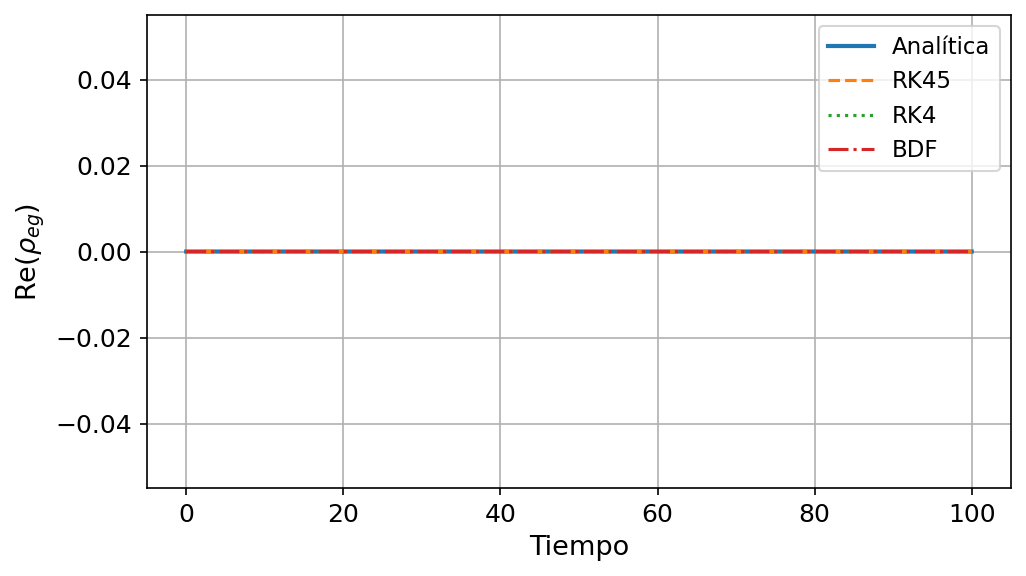

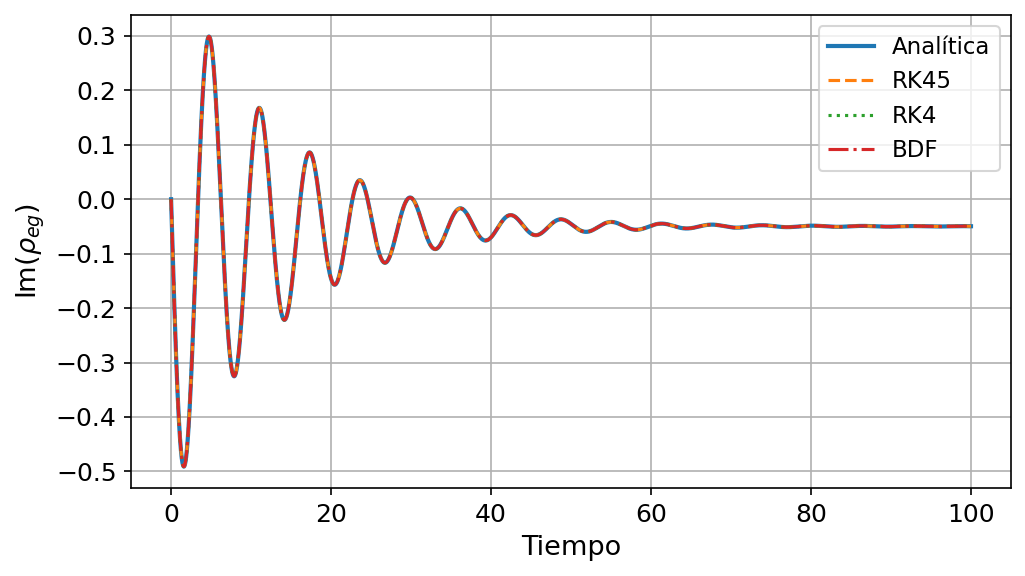

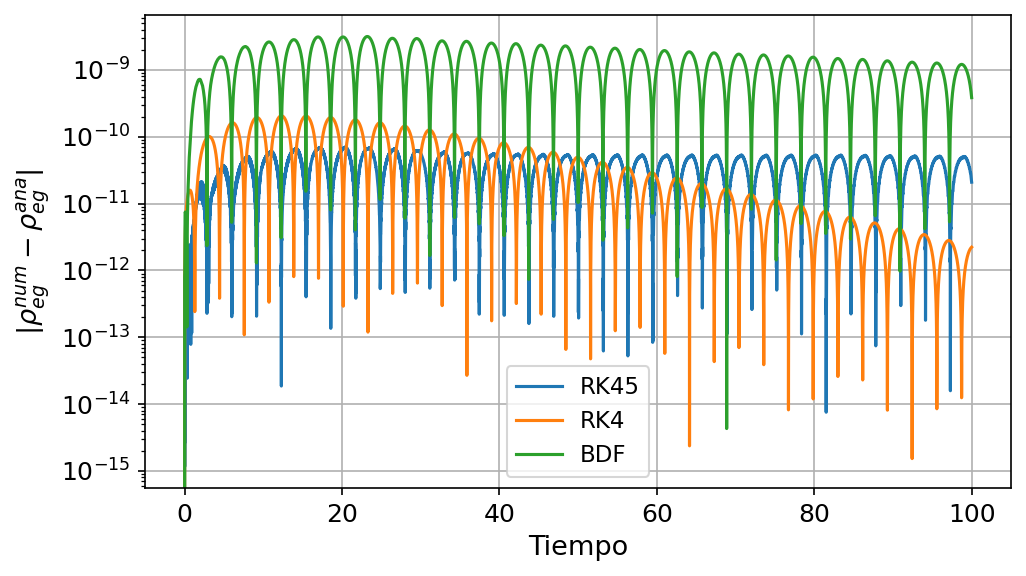

Tiempo RK45 : 0.8067 s
Tiempo RK4  : 2.1889 s
Tiempo BDF  : 1.2668 s


In [2]:
#Respecto a la Coherencia Cuantica#

#Comparacion con solucion analitica (Parte real)

plt.figure(figsize=(7,4))
plt.plot(t_eval, np.real(Mdensity_eg_analitica), linewidth=2, label="Analítica")
plt.plot(t_RK45, np.real(Mdensity_eg_RK45), "--", label="RK45")
plt.plot(t_RK4, np.real(Mdensity_eg_RK4), ":", label="RK4")
plt.plot(t_BDF, np.real(Mdensity_eg_BDF), "-.", label="BDF")
plt.xlabel("Tiempo")
plt.ylabel(r"$\mathrm{Re}(\rho_{eg})$")
plt.legend()
plt.tight_layout()
plt.show()

#Comparacion con solucion analitica (Parte imaginaria)

plt.figure(figsize=(7,4))
plt.plot(t_eval, np.imag(Mdensity_eg_analitica), linewidth=2, label="Analítica")
plt.plot(t_RK45, np.imag(Mdensity_eg_RK45), "--", label="RK45")
plt.plot(t_RK4, np.imag(Mdensity_eg_RK4), ":", label="RK4")
plt.plot(t_BDF, np.imag(Mdensity_eg_BDF), "-.", label="BDF")
plt.xlabel("Tiempo")
plt.ylabel(r"$\mathrm{Im}(\rho_{eg})$")
plt.legend()
plt.tight_layout()
plt.show()

#Error absoluto de la coherencia

plt.figure(figsize=(7,4))
plt.semilogy(t_eval, error_coh_RK45, label="RK45")
plt.semilogy(t_eval, error_coh_RK4, label="RK4")
plt.semilogy(t_eval, error_coh_BDF, label="BDF")
plt.xlabel("Tiempo")
plt.ylabel(r"$|\rho_{eg}^{num}-\rho_{eg}^{ana}|$")
plt.legend()
plt.tight_layout()
plt.show()

##########################################
#           Tiempos de Ejecucion         #
##########################################

print(f"Tiempo RK45 : {tiempo_RK45:.4f} s")
print(f"Tiempo RK4  : {tiempo_RK4:.4f} s")
print(f"Tiempo BDF  : {tiempo_BDF:.4f} s")

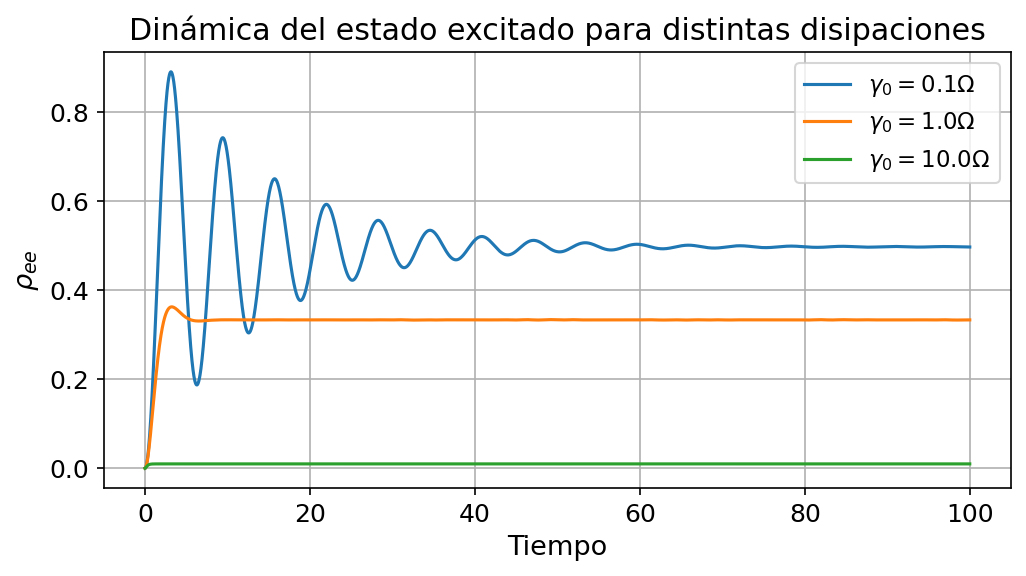

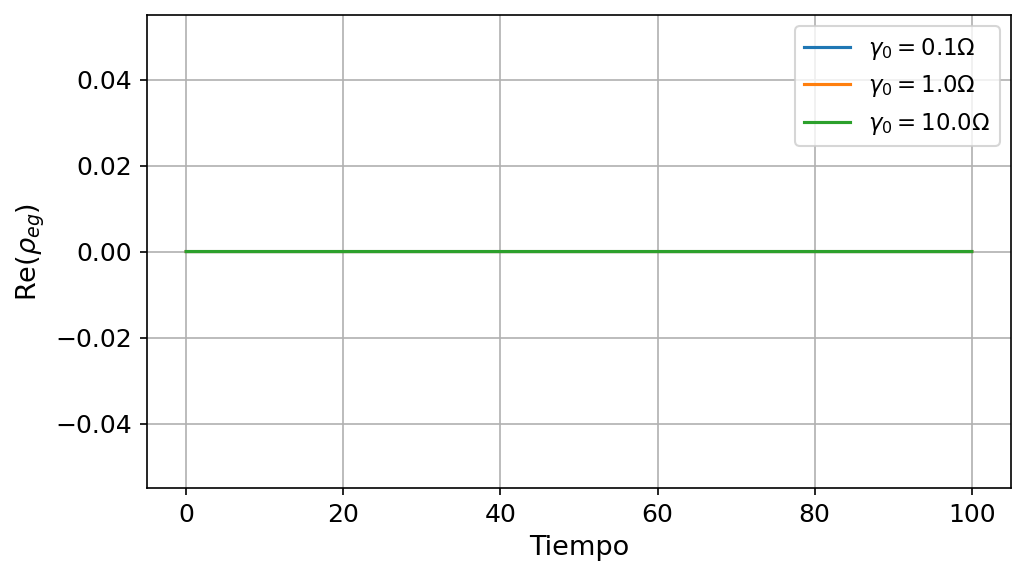

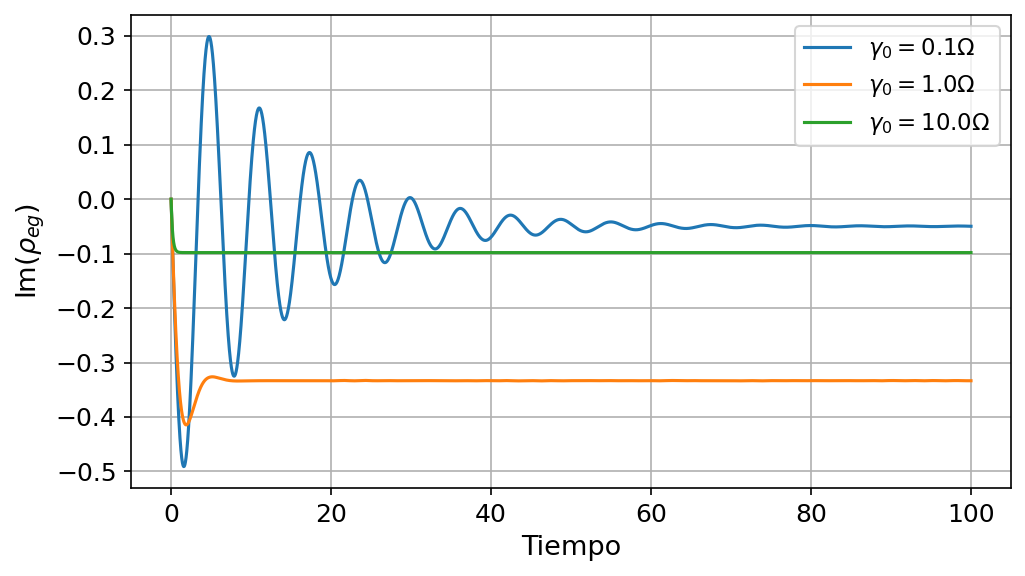

In [3]:
#########################################################################
#           Dinamica Temporal del Sistema de dos Niveles                #
#########################################################################

##########################################
#        Efectos de la disipacion        #
##########################################

Gammas = [0.1*Omega, Omega, 10*Omega]                                     #Lista de 3 regimenes de disipaciones

#Poblacion en el estado excitado

plt.figure(figsize=(7,4))

for Gamma_i in Gammas:
    rates=[Gamma_i]
    sol=solve_ivp(Lindblad, (0,100), Mdensity_0, t_eval=t_eval, args=(H,Loper,rates))
    Mdensity_ee, Mdensity_gg, Mdensity_eg, Mdensity_ge=density_elements(sol.y.T)
    plt.plot(t_eval, Mdensity_ee, label=rf"$\gamma_0={Gamma_i/Omega}\Omega$")

plt.xlabel("Tiempo")
plt.ylabel(r"$\rho_{ee}$")
plt.title("Dinámica del estado excitado para distintas disipaciones")
plt.legend()
plt.tight_layout()
plt.show()

#Coherencias Cuanticas

#Parte real de la coherencia

plt.figure(figsize=(7,4))

for Gamma_i in Gammas:
    rates=[Gamma_i]
    sol=solve_ivp(Lindblad, (0,100), Mdensity_0, t_eval=t_eval, args=(H,Loper,rates))
    Mdensity_ee, Mdensity_gg, Mdensity_eg, Mdensity_ge=density_elements(sol.y.T)
    plt.plot(t_eval, np.real(Mdensity_eg), label=rf"$\gamma_0={Gamma_i/Omega}\Omega$")

plt.xlabel("Tiempo")
plt.ylabel(r"$\mathrm{Re}(\rho_{eg})$")
plt.legend()
plt.tight_layout()
plt.show()

#Parte imaginaria de la coherencia

plt.figure(figsize=(7,4))

for Gamma_i in Gammas:
    rates=[Gamma_i]
    sol=solve_ivp(Lindblad, (0,100), Mdensity_0,t_eval=t_eval, args=(H,Loper,rates))
    Mdensity_ee, Mdensity_gg, Mdensity_eg, Mdensity_ge=density_elements(sol.y.T)
    plt.plot(t_eval, np.imag(Mdensity_eg), label=rf"$\gamma_0={Gamma_i/Omega}\Omega$")

plt.xlabel("Tiempo")
plt.ylabel(r"$\mathrm{Im}(\rho_{eg})$")
plt.legend()
plt.tight_layout()
plt.show()


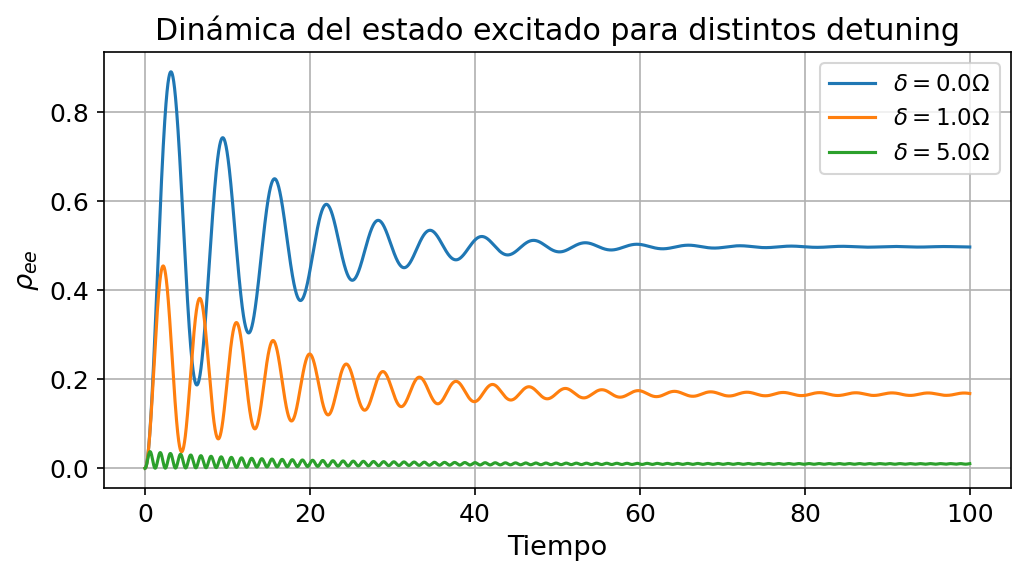

In [4]:
##########################################
#          Efectos del detuning          #
##########################################

Gamma = 0.1*Omega
rates = [Gamma]
Deltas=[0, Omega, 5*Omega]                                                     #Lista de los detuning que utilizaremos

plt.figure(figsize=(7,4))

for delta_i in Deltas:                                                         #Debemos resolver la dinamica para cada detuning
    H=-(delta_i/2)*sigma_z + (Omega/2)*sigma_x
    sol=solve_ivp(Lindblad, (0,100), Mdensity_0, t_eval=t_eval,args=(H,Loper,rates))
    Mdensity_ee, Mdensity_gg, Mdensity_eg, Mdensity_ge=density_elements(sol.y.T)
    plt.plot(t_eval, Mdensity_ee, label=rf"$\delta={delta_i/Omega}\Omega$")

plt.xlabel("Tiempo")
plt.ylabel(r"$\rho_{ee}$")
plt.title("Dinámica del estado excitado para distintos detuning")
plt.legend()
plt.tight_layout()
plt.show()

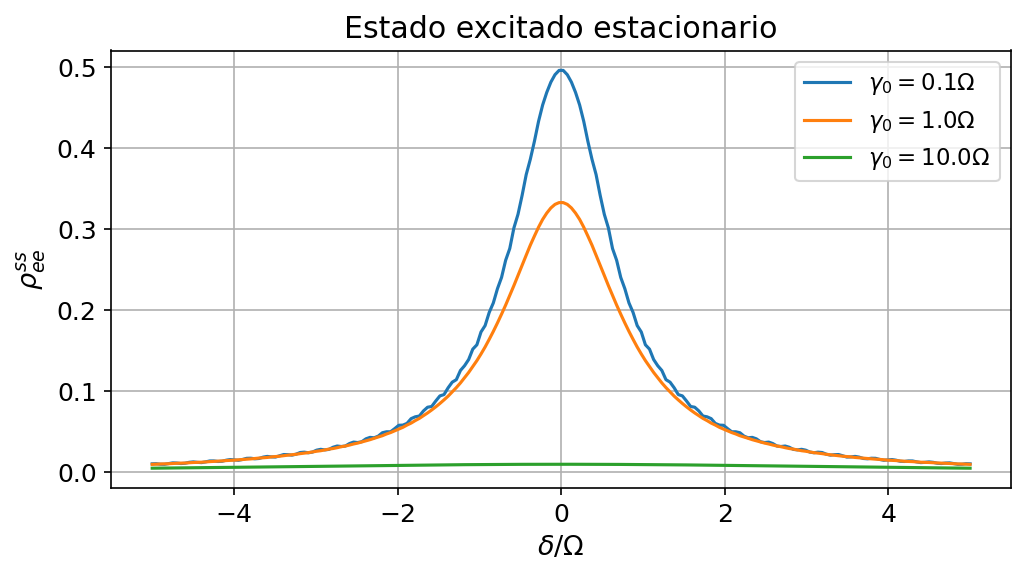

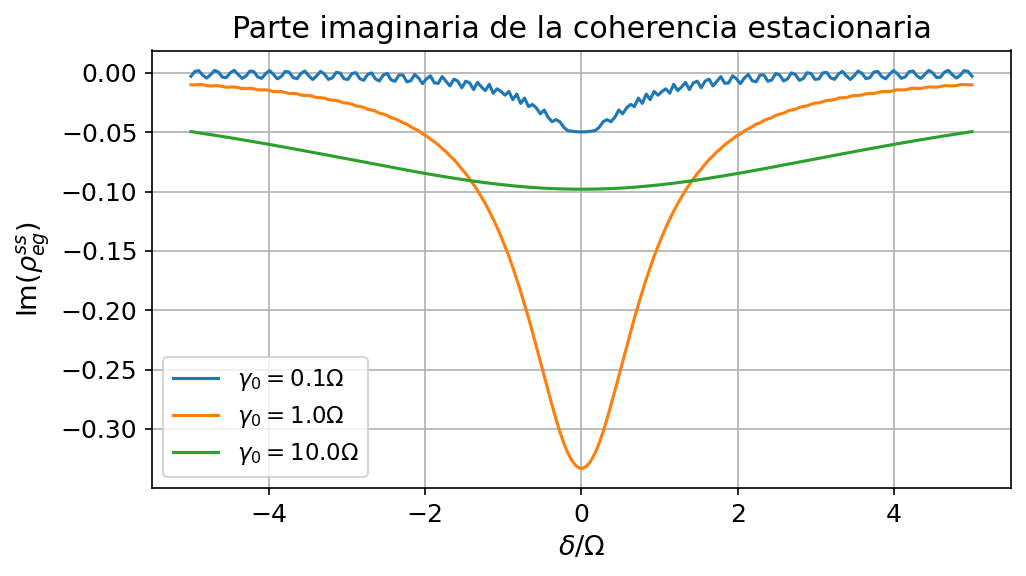

In [5]:
#########################################################################
#                      Estados Estacionarios                            #
#########################################################################

Gammas=[0.1*Omega, Omega, 10*Omega]                                                #Distintos valores de disipacion
deltas=np.linspace(-5*Omega, 5*Omega, 200)                                         #Barrido de frecuencia

#Poblacion en el estado excitado

plt.figure(figsize=(7,4))

for Gamma_i in Gammas:                                                             #Ciclo que genera espectro para cada disipacion                              
    rates=[Gamma_i]                                                                #Guardo disipacion
    Est_estacionario=[]                                                            #Lista que guarda el valor de estado estacionario para cada detuning
    for delta_i in deltas:                                                         #Recorro todos los detuning
        H=-(delta_i/2)*sigma_z + (Omega/2)*sigma_x
        sol=solve_ivp(Lindblad,(0,100),Mdensity_0,t_eval=t_eval,args=(H,Loper,rates))
        Mdensity_ee, Mdensity_gg, Mdensity_eg, Mdensity_ge=density_elements(sol.y.T)
        Est_estacionario.append(Mdensity_ee[-1])                                   #Valor estacionario para cierta disipacion y detuning
    plt.plot(deltas/Omega, Est_estacionario, label=rf"$\gamma_0={Gamma_i/Omega}\Omega$")

plt.xlabel(r"$\delta/\Omega$")
plt.ylabel(r"$\rho_{ee}^{ss}$")
plt.title("Estado excitado estacionario")
plt.legend()
plt.tight_layout()
plt.show()

#Coherencia parte imaginaria

plt.figure(figsize=(7,4))

for Gamma_i in Gammas:                                                             #Ciclo que genera espectro para cada disipacion                              
    rates=[Gamma_i]                                                                #Guardo disipacion
    Est_estacionario=[]                                                            #Lista que guarda el valor de estado estacionario para cada detuning
    for delta_i in deltas:                                                         #Recorro todos los detuning
        H=-(delta_i/2)*sigma_z + (Omega/2)*sigma_x
        sol=solve_ivp(Lindblad,(0,100),Mdensity_0,t_eval=t_eval,args=(H,Loper,rates))
        Mdensity_ee, Mdensity_gg, Mdensity_eg, Mdensity_ge=density_elements(sol.y.T)
        Est_estacionario.append(np.imag(Mdensity_eg[-1]))                          #Valor estacionario para cierta disipacion y detuning
    plt.plot(deltas/Omega, Est_estacionario, label=rf"$\gamma_0={Gamma_i/Omega}\Omega$")

plt.xlabel(r"$\delta/\Omega$")
plt.ylabel(r"$\mathrm{Im}(\rho_{eg}^{ss})$")
plt.title("Parte imaginaria de la coherencia estacionaria")
plt.legend()
plt.tight_layout()
plt.show()

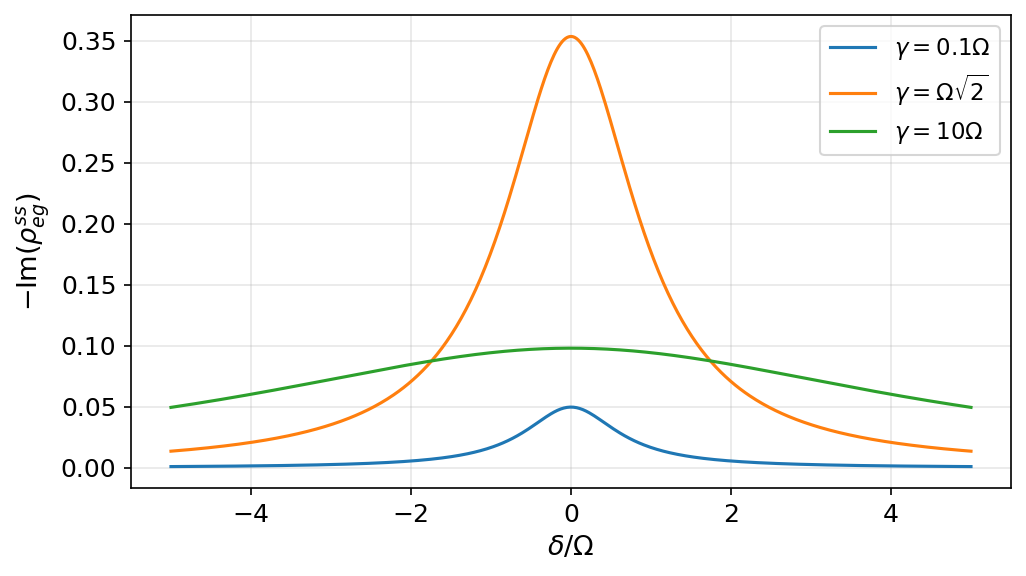

In [6]:
#########################################################################
#                      Susceptibilidad (Sin Doppler)                    #
#########################################################################

def rhoeg_ss(delta, Omega, Gamma):                      #Coherencia estacionaria obtenida desde las ecuaciones opticas de Bloch
    A=-Omega*(2*delta + 1j*Gamma)
    B=Gamma**2 + 4*delta**2 + 2*Omega**2

    return A/B

##########################################
# Espectro de Absorcion (Disipacion fija)#
##########################################

deltas=np.linspace(-5*Omega, 5*Omega, 500)
Gammas=[0.1*Omega, np.sqrt(2)*Omega, 10*Omega]                                          #Utilizo sqrt(2)*Omega por que es el maximo teorico
Leyendas=[r"$\gamma=0.1\Omega$",r"$\gamma=\Omega\sqrt{2}$",r"$\gamma=10\Omega$"]

plt.figure(figsize=(7,4))

for Gamma, leyenda in zip(Gammas, Leyendas):
    Coherencias=rhoeg_ss(deltas, Omega, Gamma)
    Absorcion=-np.imag(Coherencias)
    plt.plot(deltas/Omega, Absorcion, label=leyenda)

plt.xlabel(r"$\delta/\Omega$")
plt.ylabel(r"$-\mathrm{Im}(\rho_{eg}^{ss})$")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

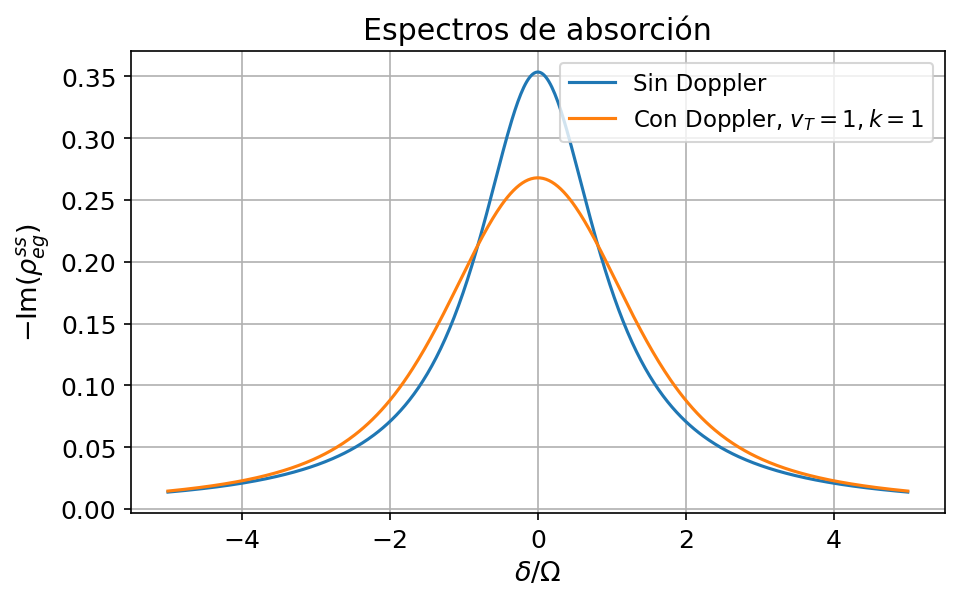

In [7]:
#########################################################################
#                      Susceptibilidad (Con Doppler)                    #
#########################################################################

##########################################
#    Distribucion de Maxwell-Boltzmann   #
##########################################

def MB(v):                                                                          #Distribucion de Maxwell-Boltzmann 1D
    return (1/(v_T*np.sqrt(np.pi)))*np.exp(-(v/v_T)**2)

k=1                                                                                 #Elijo valores de numero de onda y velocidad termica adimensionales
v_T=1

Gamma=Omega*np.sqrt(2)

def chi_doppler(delta):                                                             #Integracion para distintas velocidades
    velocidades=np.linspace(-5*v_T,5*v_T,1000)                                      #Arreglo de diversas velocidades
    integrando=(MB(velocidades)*rhoeg_ss(delta-k*velocidades, Omega, Gamma))        #Parte imaginaria de la susceptibilidad

    return np.trapezoid(integrando,velocidades)

#########################################################################
#Comparacion de caso sin Doppler y con Doppler (Disipacion Omega sqrt(2))#
#########################################################################

deltas=np.linspace(-5*Omega,5*Omega,500)
Coherencias=rhoeg_ss(deltas, Omega, Gamma)
Absorcion=-np.imag(Coherencias)                                                     #Absorcion sin Doppler
Chi_D=np.array([chi_doppler(delta)for delta in deltas])                             #Construyo el espectro en base a todos los valores respecto al detuning
Absorcion_Doppler=-np.imag(Chi_D)      

plt.figure(figsize=(7,4))
plt.plot(deltas/Omega, Absorcion, label="Sin Doppler")
plt.plot(deltas/Omega, Absorcion_Doppler, label=rf"Con Doppler, $v_T={v_T}, k=1$")
plt.xlabel(r"$\delta/\Omega$")
plt.ylabel(r"$-\mathrm{Im}(\rho_{eg}^{ss})$")
plt.title("Espectros de absorción")
plt.legend()
